# ISDS 7075 Summer 2026 - Group 4 Project

## Chronic Kidney Disease Analysis

### Group Members: Thais Diaz, Cody Tatom, Rhonda Swider

## Wrangling of Data

In [149]:
#Import required packages

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

#Figures inline and set visualization style
%matplotlib inline
sns.set()


### Import the data

In [150]:
df_kd = pd.read_excel("../data/ML_project_kidney_disease.xlsx")
df_kd_fields = pd.read_excel("../data/ML_project_kidney_disease.xlsx", sheet_name = "Fields")

In [94]:
df_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Identify Missing Values
Total number of rows is 400. 
Missing values in almost all fields.  


In [95]:
df_kd.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,CKD_class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1


### Investigate Data Structure/dictionary

In [96]:
#Investigate data structure/dictionary from reference info on website
#This pulls in from second sheettab appended in Excel data file
df_kd_fields

,Name,Description,Type,value_info
0,age,age,Integer,age in years
1,bp,blood pressure,Integer,bp in mm/Hg
2,sg,specific gravity,Categorical,"1.005,1.010,1.015,1.020,1.025"
3,al,albumin,Categorical,"0,1,2,3,4,5"
4,su,sugar,Categorical,"0,1,2,3,4,5"
5,rbc,red blood cells,Binary,"normal,abnormal"
6,pc,pus cell,Binary,"normal,abnormal"
7,pcc,pus cell clumps,Binary,"present,notpresent"
8,ba,bacteria,Binary,"present,notpresent"
9,bgr,blood gluucose random,Integer,bgr in mgs/dl


In [97]:
df_kd.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,CKD_class
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.620000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.485994
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


### Adjust for Missing values

In [98]:
#Find all "?" values, and replace with the np.nan function
df_kd.replace('?',np.nan,inplace=True)

print(df_kd.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
CKD_class           0
dtype: int64


In [99]:
#age is missing 9 values - Replace with avg age - recast as Int
#Compute avg_age
avg_age = df_kd['age'].mean(axis=0)
print("Average age: ", avg_age)
#Replace "NaN" by mean value in 'age' column
df_kd['age'].replace(np.nan, avg_age, inplace = True) 
df_kd['age'] = df_kd['age'].astype(int)


Average age:  51.48337595907928


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3199127390.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [100]:
#bp is missing 12 values - Replace with avg bp - recast as Int
#Compute avg_bp
avg_bp = df_kd['bp'].mean(axis=0)
print("Average bp: ", avg_bp)
#Replace "NaN" by mean value in 'bp' column
df_kd['bp'].replace(np.nan, avg_bp, inplace = True) 
df_kd['bp'] = df_kd['bp'].astype(int)


Average bp:  76.46907216494846


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3082993240.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [101]:
#sg is missing 47 values  -- Too many values missing?
df_kd['sg'].value_counts()
#Replace with mode
df_kd['sg'].replace(np.nan,'1.020',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\32190144.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [102]:
#al is missing 46 values -- Too many values missing?
df_kd['al'].value_counts()
#Replace with mode
df_kd['al'].replace(np.nan,'0.0',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3563785773.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [103]:
#su is missing 49 values  -- Too many values missing?
df_kd['su'].value_counts()
#Replace with mode
df_kd['su'].replace(np.nan,'0.0',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\866859059.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [104]:
#rbc is missing 152 values  -- Too many values missing?
df_kd['rbc'].value_counts()
df_kd['rbc'].replace(np.nan,'normal',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\536310735.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [105]:
#pc is missing 65 values  -- Too many values missing?
df_kd['pc'].value_counts()
#replace missing values of 'pc' with 'normal'
df_kd['pc'].replace(np.nan,'normal',inplace=True)
#df_kd['pc'].value_counts()

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1189769276.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [106]:
#pcc is missing 4 values
df_kd['pcc'].value_counts()
#replace missing values of 'pcc' with 'notpresent'
df_kd['pcc'].replace(np.nan,'notpresent', inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3059995983.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [107]:
#ba is missing 4 values
df_kd['ba'].value_counts()
#replace missing values of 'ba' with 'notpresent'
df_kd['ba'].replace(np.nan,'notpresent', inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1426584899.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [108]:
#bgr is missing 44 values - Replace with avg bgr - recast as Int
#Compute avg_bgr
avg_bgr = df_kd['bgr'].mean(axis=0)
print("Average bgr: ", avg_bgr)
#Replace "NaN" by mean value in 'bgr' column
df_kd['bgr'].replace(np.nan, avg_bgr, inplace = True) 
df_kd['bgr'] = df_kd['bgr'].astype(int)


Average bgr:  148.0365168539326


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1761785724.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [109]:
#bu is missing 19 values - Replace with avg bu - recast as Int
#Compute avg_bu
avg_bu = df_kd['bu'].mean(axis=0)
print("Average bu: ", avg_bu)
#Replace "NaN" by mean value in 'bu' column
df_kd['bu'].replace(np.nan, avg_bu, inplace = True) 
df_kd['bu'] = df_kd['bu'].astype(int)


Average bu:  57.425721784776904


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1160339228.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [110]:
#sc missing 17 values - Replace with avg sc - recast as float

#Compute avg_sc
avg_sc = df_kd['sc'].mean(axis=0)
print("Average sc: ", avg_sc)
#Replace "NaN" by mean value in 'sc' column
df_kd['sc'].replace(np.nan, avg_sc, inplace = True) 
df_kd['sc'] = df_kd['sc'].astype(int)



Average sc:  3.072454308093995


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1339582682.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [111]:
#sod missing 87 values  -- Too many values missing?
#Compute avg_sod
avg_sod = df_kd['sod'].mean(axis=0)
print("Average sod: ", avg_sod)
#Replace "NaN" by mean value in 'sod' column
df_kd['sod'].replace(np.nan, avg_sod, inplace = True) 
df_kd['sod'] = df_kd['sod'].astype(int)

Average sod:  137.52875399361022


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\2124005473.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [112]:
#pot missing 88 values  -- Too many values missing?
#Compute avg_pot
avg_pot = df_kd['pot'].mean(axis=0)
print("Average pot: ", avg_pot)
#Replace "NaN" by mean value in 'pot' column
df_kd['pot'].replace(np.nan, avg_pot, inplace = True) 
df_kd['pot'] = df_kd['pot'].astype(int)

Average pot:  4.62724358974359


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\353393420.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [113]:
#hemo missing 52 values  -- Too many values missing?
#Compute avg_pot
avg_hemo = df_kd['hemo'].mean(axis=0)
print("Average hemo: ", avg_hemo)
#Replace "NaN" by mean value in 'hemo' column
df_kd['hemo'].replace(np.nan, avg_hemo, inplace = True) 
df_kd['hemo'] = df_kd['hemo'].astype(int)

Average hemo:  12.526436781609195


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1676046407.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [114]:
#pcv missing 70 values  -- Too many values missing?
#Compute avg_pcv
df_kd['pcv'].replace('?',np.nan,inplace=True)
df_kd['pcv']=pd.to_numeric(df_kd['pcv'],errors='coerce')
avg_pcv = df_kd['pcv'].mean(axis=0)
print("Average pcv: ",avg_pcv)
df_kd['pcv'].replace(np.nan,avg_pcv,inplace = True)



Average pcv:  38.88449848024316


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\2347280484.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\2347280484.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [115]:
#wc missing 105 values  -- Too many values missing?
#Compute avg_wc
df_kd['wc'].replace('?',np.nan,inplace=True)
df_kd['wc']=pd.to_numeric(df_kd['wc'],errors='coerce')
avg_wc = df_kd['wc'].mean(axis=0)
print("Average wc: ",avg_wc)
df_kd['wc'].replace(np.nan,avg_wc,inplace = True)


Average wc:  8406.122448979591


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\220537180.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\220537180.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [116]:
#rc missing 130 values  -- Too many values missing?
df_kd['rc'].replace('?',np.nan,inplace=True)
df_kd['rc']=pd.to_numeric(df_kd['rc'],errors='coerce')
avg_rc = df_kd['rc'].mean(axis=0)
print("Average rc: ",avg_rc)
df_kd['rc'].replace(np.nan,avg_rc,inplace = True)

Average rc:  4.707434944237917


C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3202980580.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\3202980580.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [117]:
#htn missing 2 values
df_kd['htn'].value_counts()
#Replace with max count value
df_kd['htn'].replace(np.nan,'no',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\2706430390.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [118]:
#dm missing 2 values
df_kd['dm'].value_counts()
#Replace with max count value
df_kd['dm'].replace(' yes','yes', inplace=True)
df_kd['dm'].replace('\tyes','yes',inplace=True)
df_kd['dm'].replace('\tno','no',inplace=True)
df_kd['dm'].replace(np.nan,'no',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\4212325705.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\4212325705.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [119]:
#cad missing 2 values 
df_kd['cad'].value_counts()
#Replace with max count value
df_kd['cad'].replace(np.nan,'no',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\2283293214.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [120]:
#appet missing 1 value
df_kd['appet'].value_counts()
#Replace with max count value
df_kd['appet'].replace(np.nan,'good',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\668089827.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [121]:
#pe missing 1 value
df_kd['pe'].value_counts()
#Replace with max count value
df_kd['pe'].replace(np.nan,'no',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\389680503.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [122]:
#ane missing 1 value
df_kd['ane'].value_counts()
#Replace with max count value
df_kd['ane'].replace(np.nan,'no', inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\1661931810.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [123]:
df_kd['classification'].replace('ckd\t','ckd',inplace=True)

C:\Users\RhondaSwider\AppData\Local\Temp\ipykernel_28860\451479431.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [124]:
df_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    int32  
 2   bp              400 non-null    int32  
 3   sg              400 non-null    object 
 4   al              400 non-null    object 
 5   su              400 non-null    object 
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    int32  
 11  bu              400 non-null    int32  
 12  sc              400 non-null    int32  
 13  sod             400 non-null    int32  
 14  pot             400 non-null    int32  
 15  hemo            400 non-null    int32  
 16  pcv             400 non-null    float64
 17  wc              400 non-null    flo

### Correct data format


### Data Normalization

### Binning

### Visualizations

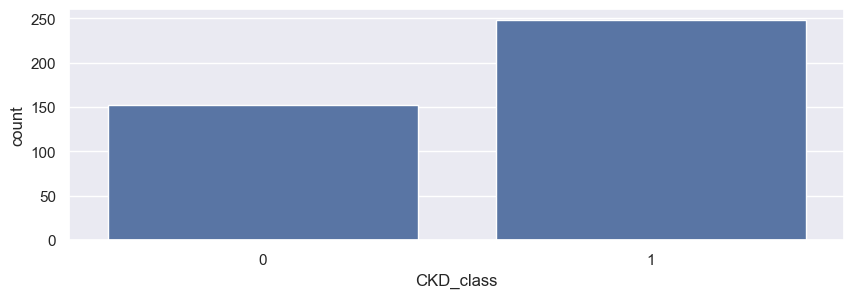

In [126]:
plt.figure(figsize=(10,3))
sns.countplot(x=df_kd['CKD_class'])
plt.show()

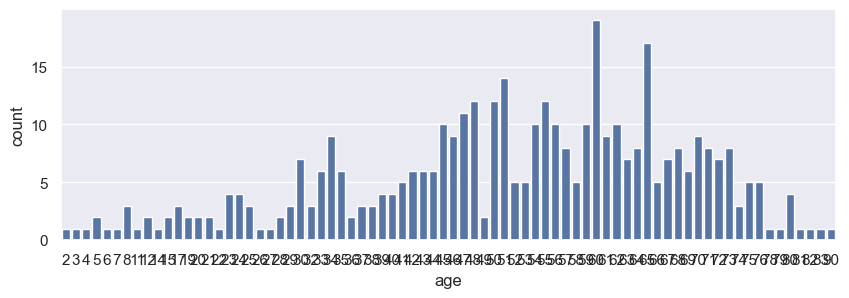

In [127]:
plt.figure(figsize=(10,3))  ##########Need to Bin
sns.countplot(x=df_kd['age'])
plt.show()

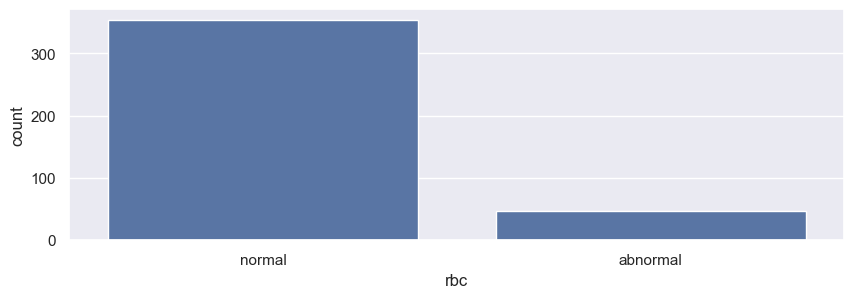

In [128]:
plt.figure(figsize=(10,3))
sns.countplot(x=df_kd['rbc'])
plt.show()

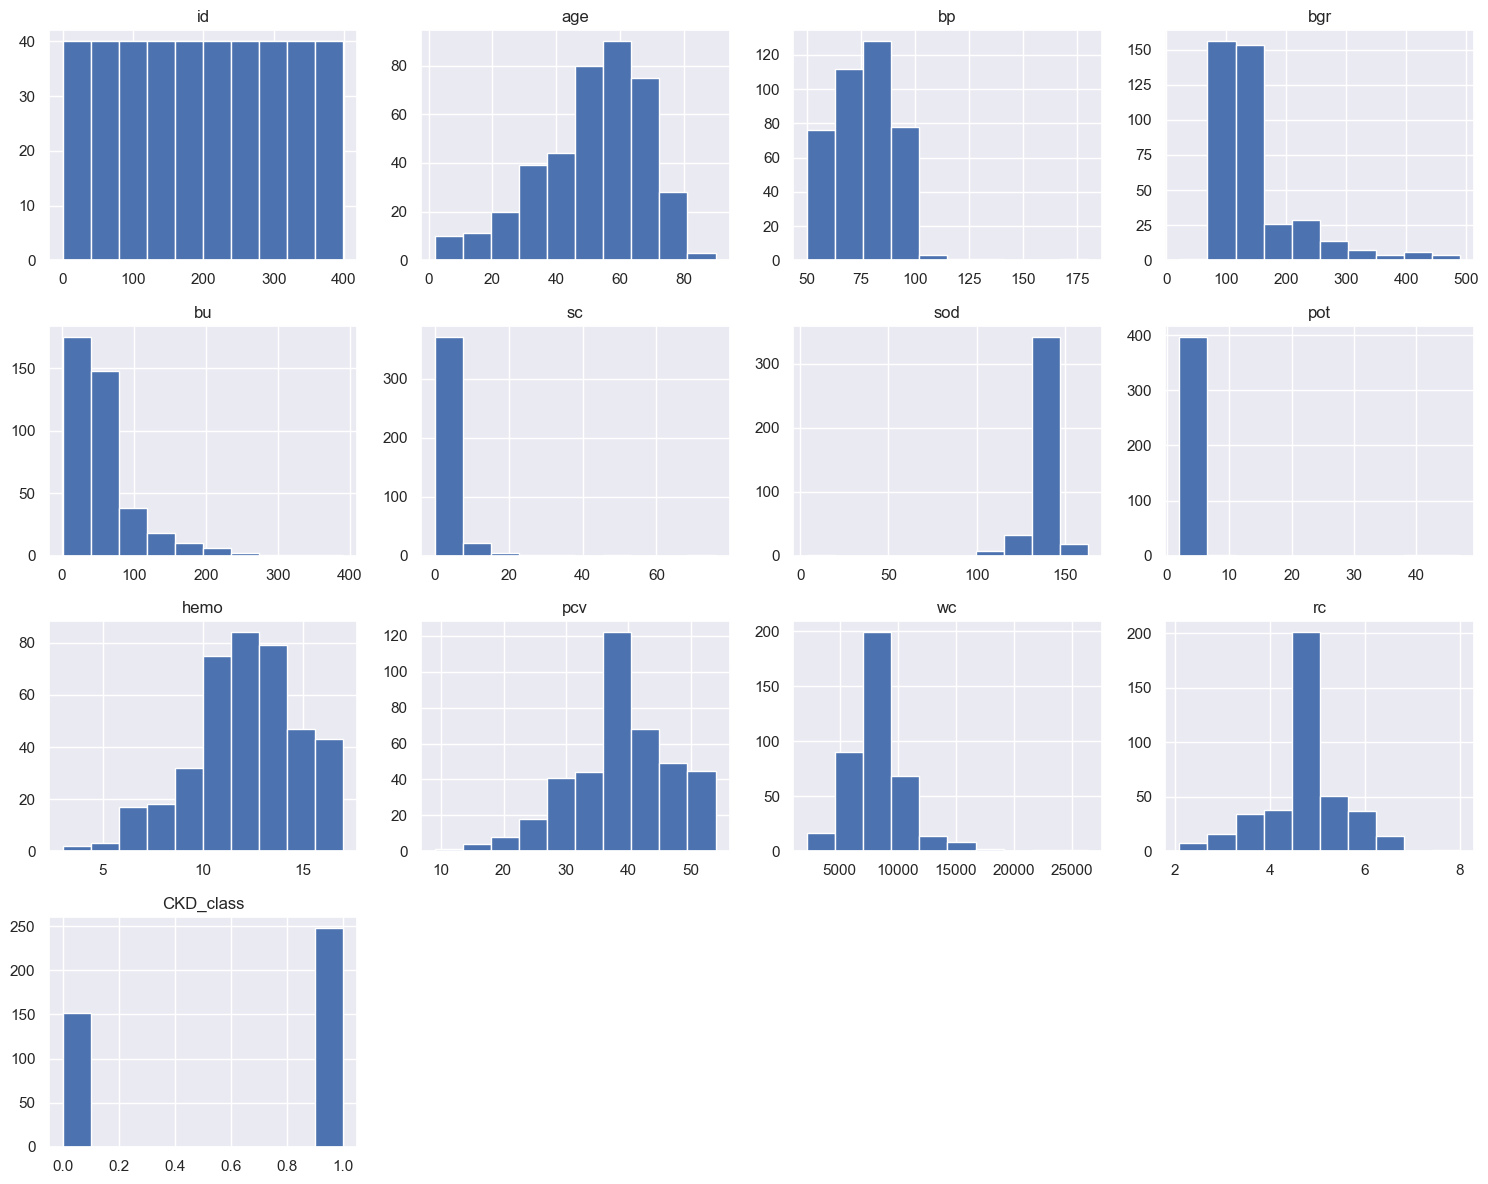

In [129]:
df_kd.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

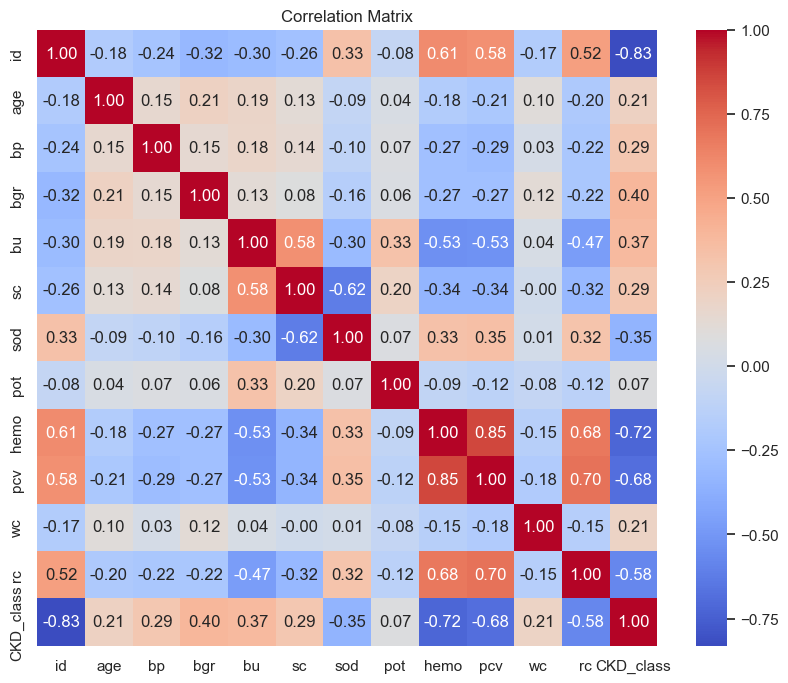

In [130]:
plt.figure(figsize=(10,8))

correlation = df_kd.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [131]:
import plotly.express as px
vis = px.scatter(df_kd, x="pcv", y="rc", color="classification")
vis.show()

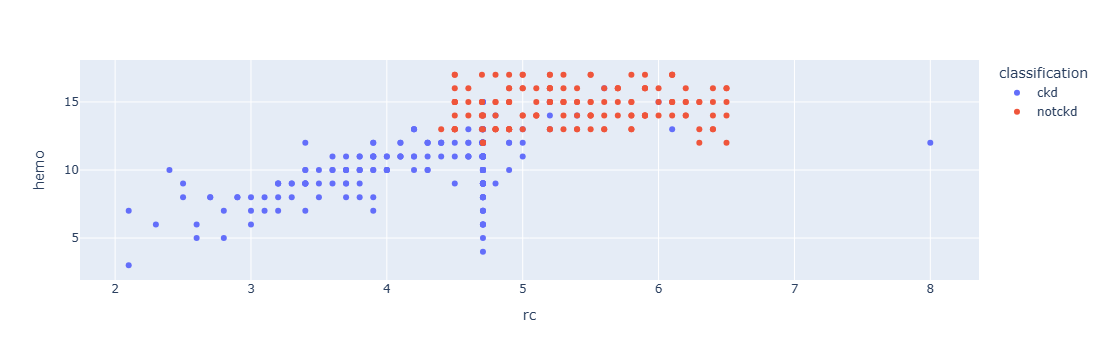

In [144]:
import plotly.express as px
vis = px.scatter(df_kd, x="rc", y="hemo", color="classification")
vis.show()

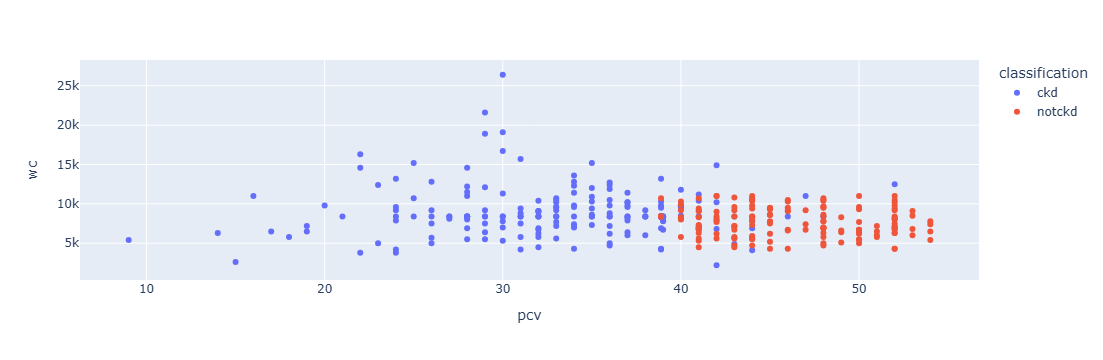

In [147]:
import plotly.express as px
vis = px.scatter(df_kd, x="pcv", y="wc", color="classification")
vis.show()


# Create the training and testing datasets


In [152]:
#############Need to fix this

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

NameError: name 'train_test_split' is not defined

In [ ]:
print(X_train.shape)
print(X_test.shape)